
# JWST NIRCAM

Aligning JWST/NIRCAM images with JHAT.


An example NIRCam Dataset is downloaded, and then a series of
alignment methods are used. For more information on the
key parameters used for alignment see 
`params:Useful Parameters`.



In [1]:
import sys,os,glob
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy import wcs
from astropy.wcs.utils import skycoord_to_pixel
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from astroquery.mast import Observations
from astropy.visualization import (simple_norm,LinearStretch)

import jhat
from jhat import jwst_photclass,st_wcs_align

The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


## Relative Alignment

**Download some Data**

For this example we download 2 JWST NIRCam images from MAST. They're
the same field but different filters. Note that 
the code will also work for level 3 data images.



In [2]:
obs_table1 = Observations.query_criteria(obs_id='jw02107-o041_t019_nircam_clear-f200w')
data_products_by_obs = Observations.get_product_list(obs_table1)
data_products_by_obs = data_products_by_obs[data_products_by_obs['calib_level']==2]
data_products_by_obs = data_products_by_obs[data_products_by_obs['productSubGroupDescription']=='CAL'][0]
Observations.download_products(data_products_by_obs,extension='fits')

obs_table2 = Observations.query_criteria(obs_id='jw02107-o041_t019_nircam_clear-f360m')
data_products_by_obs = Observations.get_product_list(obs_table2)
data_products_by_obs = data_products_by_obs[data_products_by_obs['calib_level']==2]
data_products_by_obs = data_products_by_obs[data_products_by_obs['productSubGroupDescription']=='CAL'][0]
Observations.download_products(data_products_by_obs,extension='fits')

Local Path,Status,Message,URL
str98,str8,object,object
./mastDownload/JWST/jw02107041001_02101_00003_nrcblong/jw02107041001_02101_00003_nrcblong_cal.fits,COMPLETE,None,None


**Examine the Reference Image**




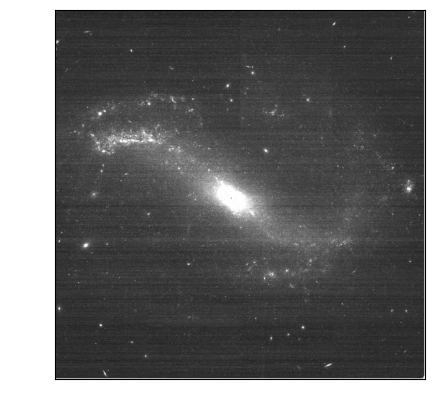

In [10]:

ref_image = glob.glob('mastDownload/JWST/*nrcb*/*cal.fits')[0]

ref_fits = fits.open(ref_image)
ref_data = fits.open(ref_image)['SCI',1].data
norm1 = simple_norm(ref_data,stretch='linear',min_cut=-.5,max_cut=3)

plt.imshow(ref_data, origin='lower',
                      norm=norm1,cmap='gray')
plt.gca().tick_params(labelcolor='none',axis='both',color='none')
plt.show()

**Zoom in to see the offset**

Here add an artificial offset to the wcs, and then we see the 
same star in both images at the same ra/dec
location, demonstrating a large offset between
the images.  



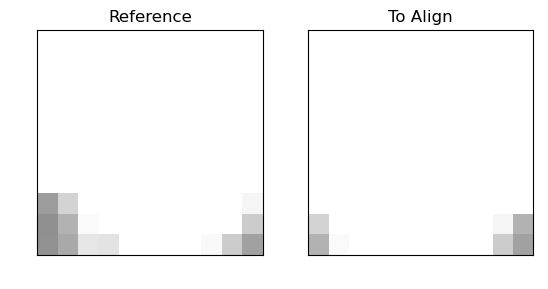

In [11]:
star_location = SkyCoord('23:09:41.0532','-43:26:41.128',unit=(u.hourangle,u.deg))
align_image = glob.glob('mastDownload/JWST/*long*/*cal.fits')[0]
align_fits = fits.open(align_image)
align_fits['SCI',1].header['CRPIX1']+=1
align_fits['SCI',1].header['CRPIX2']+=1
align_fits.writeto(align_image,overwrite=True)

align_data = fits.open(align_image)['SCI',1].data
ref_y,ref_x = skycoord_to_pixel(star_location,wcs.WCS(ref_fits['SCI',1],ref_fits))
align_y,align_x = skycoord_to_pixel(star_location,wcs.WCS(align_fits['SCI',1],align_fits))

ref_cutout = extract_array(ref_data,(11,11),(ref_x,ref_y))
align_cutout = extract_array(align_data,(11,11),(align_x,align_y))
norm1 = simple_norm(ref_cutout,stretch='linear',min_cut=-.5,max_cut=3)
norm2 = simple_norm(align_cutout,stretch='linear',min_cut=-.5,max_cut=3)
fig,axes = plt.subplots(1,2)
axes[0].imshow(ref_cutout, origin='lower',
                      norm=norm1,cmap='gray')
axes[1].imshow(align_cutout, origin='lower',
                      norm=norm2,cmap='gray')
axes[0].set_title('Reference')
axes[1].set_title('To Align')
axes[0].tick_params(labelcolor='none',axis='both',color='none')
axes[1].tick_params(labelcolor='none',axis='both',color='none')

plt.show()

**Create a Photometric Catalog for Relative Alignment**

We choose one of the images to be the reference image, and then 
create a catalog that we will use to align the other image.



In [12]:
jwst_phot = jwst_photclass()
jwst_phot.run_phot(imagename=ref_image,photfilename='auto',overwrite=True,ee_radius=80)
ref_catname = ref_image.replace('.fits','.phot.txt') # the default
refcat = Table.read(ref_catname,format='ascii')
print(refcat)

0 mastDownload/JWST/jw02107041001_02101_00003_nrcblong/jw02107041001_02101_00003_nrcblong_cal.phot.txt
find_stars


2026-09-04 13:16:57,048 - CRDS - ERROR -  (FATAL) CRDS server connection and cache load FAILED.  Cannot continue.
 See https://jwst-crds.stsci.edu/docs/cmdline_bestrefs/
 for more information on configuring CRDS, particularly CRDS_PATH and CRDS_SERVER_URL. : [Errno 2] No such file or directory: '/grp/crds/cache/config/jwst/server_config'


dmag 0.36200000000000004
aper_sum_3.0px annulus_median_3.0px aper_bkg_3.0px ...     RA        DEC    
-------------- -------------------- -------------- ... ---------- ----------
     17.463873             0.134735       3.809532 ... 347.470351 -43.443687
       9.11123             0.178997       5.061025 ... 347.470138 -43.443575
    182.894892             0.501989      14.193411 ... 347.471309 -43.416024
      6.505996             0.123873       3.502431 ... 347.470401 -43.431064
      9.742506             0.165774        4.68716 ... 347.470063 -43.431047
     16.599407             0.203039       5.740783 ... 347.469493 -43.437824
     18.188881             0.315004       8.906536 ... 347.469478 -43.437684
     15.546983             0.194589       5.501863 ... 347.468986 -43.443491
    154.911752             0.802959      22.703132 ... 347.469053 -43.437906
      8.110273             0.130825       3.698998 ... 347.468508 -43.447079
           ...                  ...            ... 

**Align the second image**

The plots outputted here show the various steps used by jhat to
determine the true matching sources in the image, and the
subsequent correction needed for optimal alignment.



WWWWWWWWWWWWWWWWWWWWWWWWWWW apply_distortion_coefficients 2026-09-04 11:17:03.791192
WWWWWWWWWWWWWWWWWWWWWWWWWWW run_phot 2026-09-04 11:17:03.791701


0 ./mastDownload/jw02107041001_02101_00003_nrcblong.phot.txt
find_stars


2026-09-04 13:17:07,193 - CRDS - ERROR -  (FATAL) CRDS server connection and cache load FAILED.  Cannot continue.
 See https://jwst-crds.stsci.edu/docs/cmdline_bestrefs/
 for more information on configuring CRDS, particularly CRDS_PATH and CRDS_SERVER_URL. : [Errno 2] No such file or directory: '/grp/crds/cache/config/jwst/server_config'


dmag 0.36200000000000004
DDD NIRCAM F360M CLEAR ggg None
####### coron None
dmag 1.0
sharpness 0.9
roundness1 0.7
mag 24


WWWWWWWWWWWWWWWWWWWWWWWWWWW initial_cut_photcat 2026-09-04 11:17:08.714546
WWWWWWWWWWWWWWWWWWWWWWWWWWWXX 1pass 2026-09-04 11:17:08.722154
WWWWWWWWWWWWWWWWWWWWWWWWWWW load_and_match_refcat 2026-09-04 11:17:08.722607


x 2008
y 2008
Saving refcat file into ./mastDownload/jw02107041001_02101_00003_nrcblong.refcat.txt


WWWWWWWWWWWWWWWWWWWWWWWWWWW find_good_refcat_matches 2026-09-04 11:17:09.430612


reffile_d2d 1
*** Note: close plot to continue!


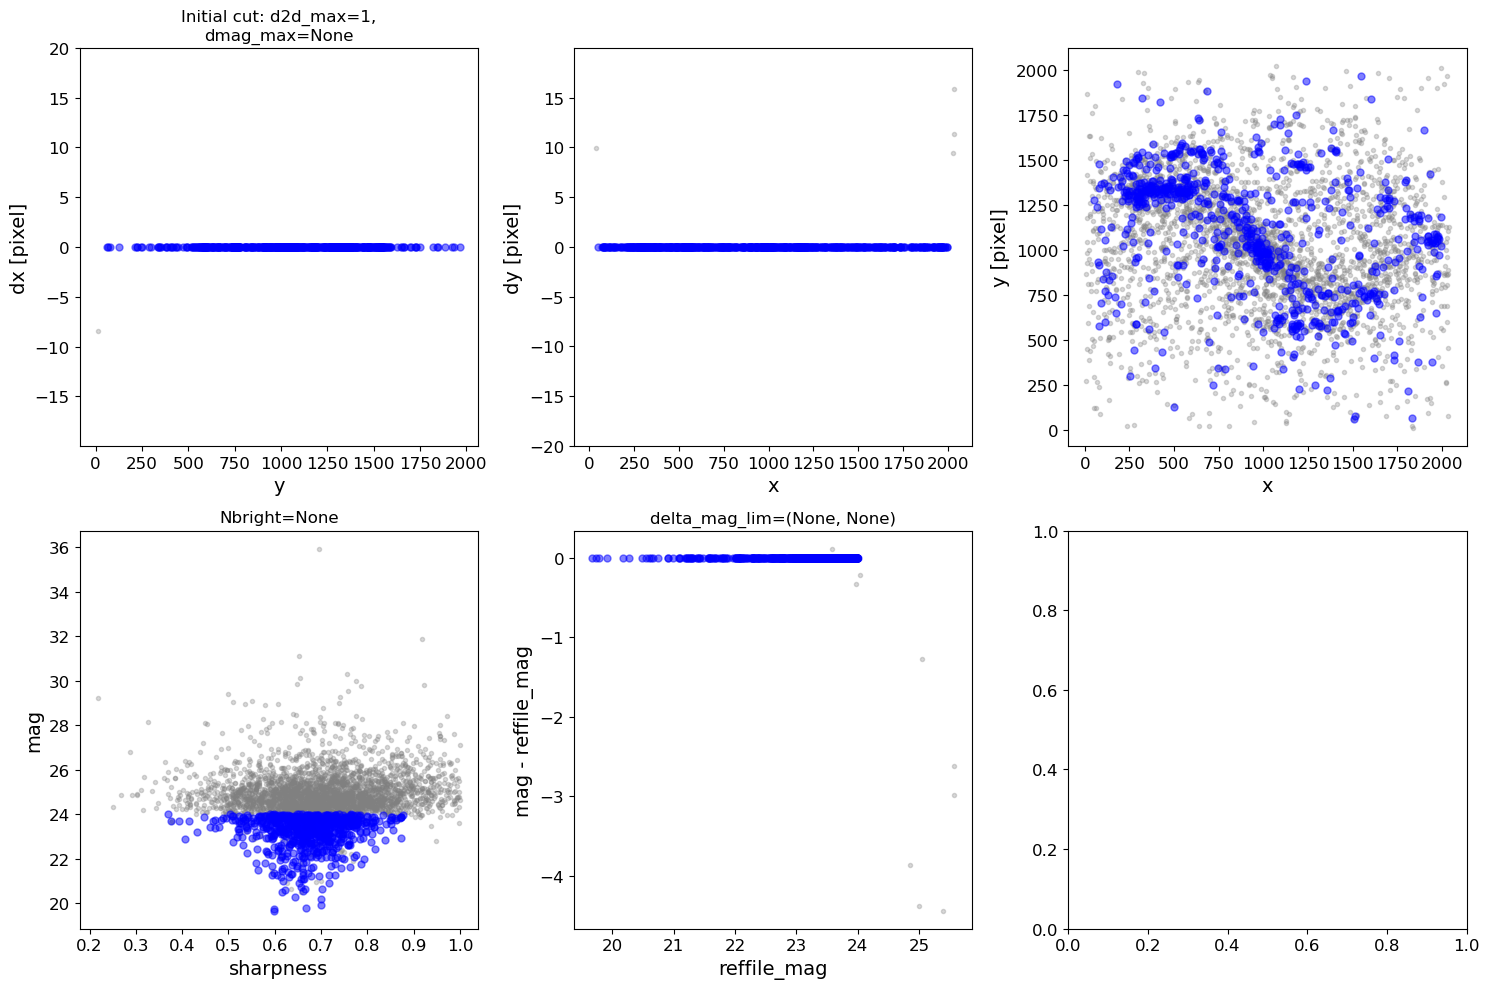

        slope    intercept     maxval  index  d_bestguess  fwhm  multimax
-1.734723e-17 1.776357e-14 720.438348   2655    -0.002588  0.48     False
d_rot_tmp 0.7974124638803162
Keeping 723 out of 723, skippin 0 because of null values in columns d_rot_tmp
median: 0.000046
75.000000 percentile cut: max residual for cut: 0.021109
__tmp_residuals 0.021109478605722556
median: 0.001004
i:00 mean:0.001004(0.000529) stdev:0.012295(0.000373) X2norm:1.00 Nchanged:0 Ngood:542 Nclip:181

mean: -0.000486
i:01 mean:-0.000486(0.000608) stdev:0.016338(0.000430) X2norm:1.00 Nchanged:181 Ngood:723 Nclip:0

mean: -0.000486
i:02 mean:-0.000486(0.000608) stdev:0.016338(0.000430) X2norm:1.00 Nchanged:0 Ngood:723 Nclip:0


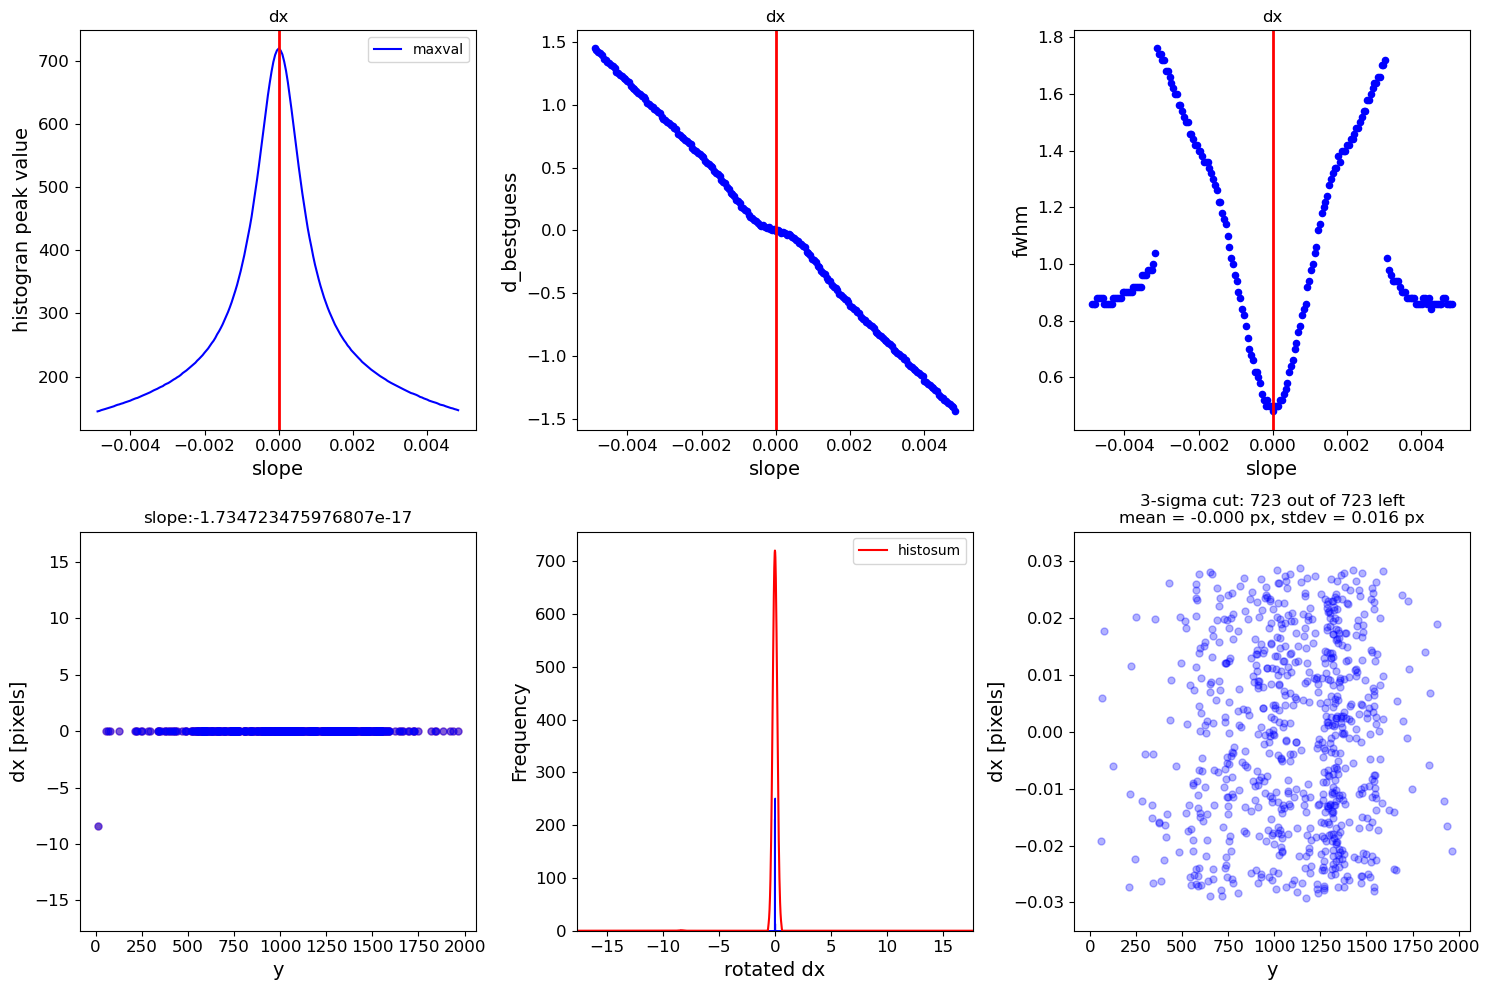

        slope    intercept     maxval  index  d_bestguess  fwhm  multimax
-1.734723e-17 1.776357e-14 721.154617     32     0.009243  0.12     False
d_rot_tmp 0.3092431091047979
Keeping 723 out of 723, skippin 0 because of null values in columns d_rot_tmp
median: -0.000406
75.000000 percentile cut: max residual for cut: 0.015049
__tmp_residuals 0.015049140359676885
median: -0.000434
i:00 mean:-0.000434(0.000365) stdev:0.008501(0.000258) X2norm:1.00 Nchanged:0 Ngood:542 Nclip:181

mean: -0.000235
i:01 mean:-0.000235(0.000428) stdev:0.011504(0.000303) X2norm:1.00 Nchanged:181 Ngood:723 Nclip:0

mean: -0.000235
i:02 mean:-0.000235(0.000428) stdev:0.011504(0.000303) X2norm:1.00 Nchanged:0 Ngood:723 Nclip:0


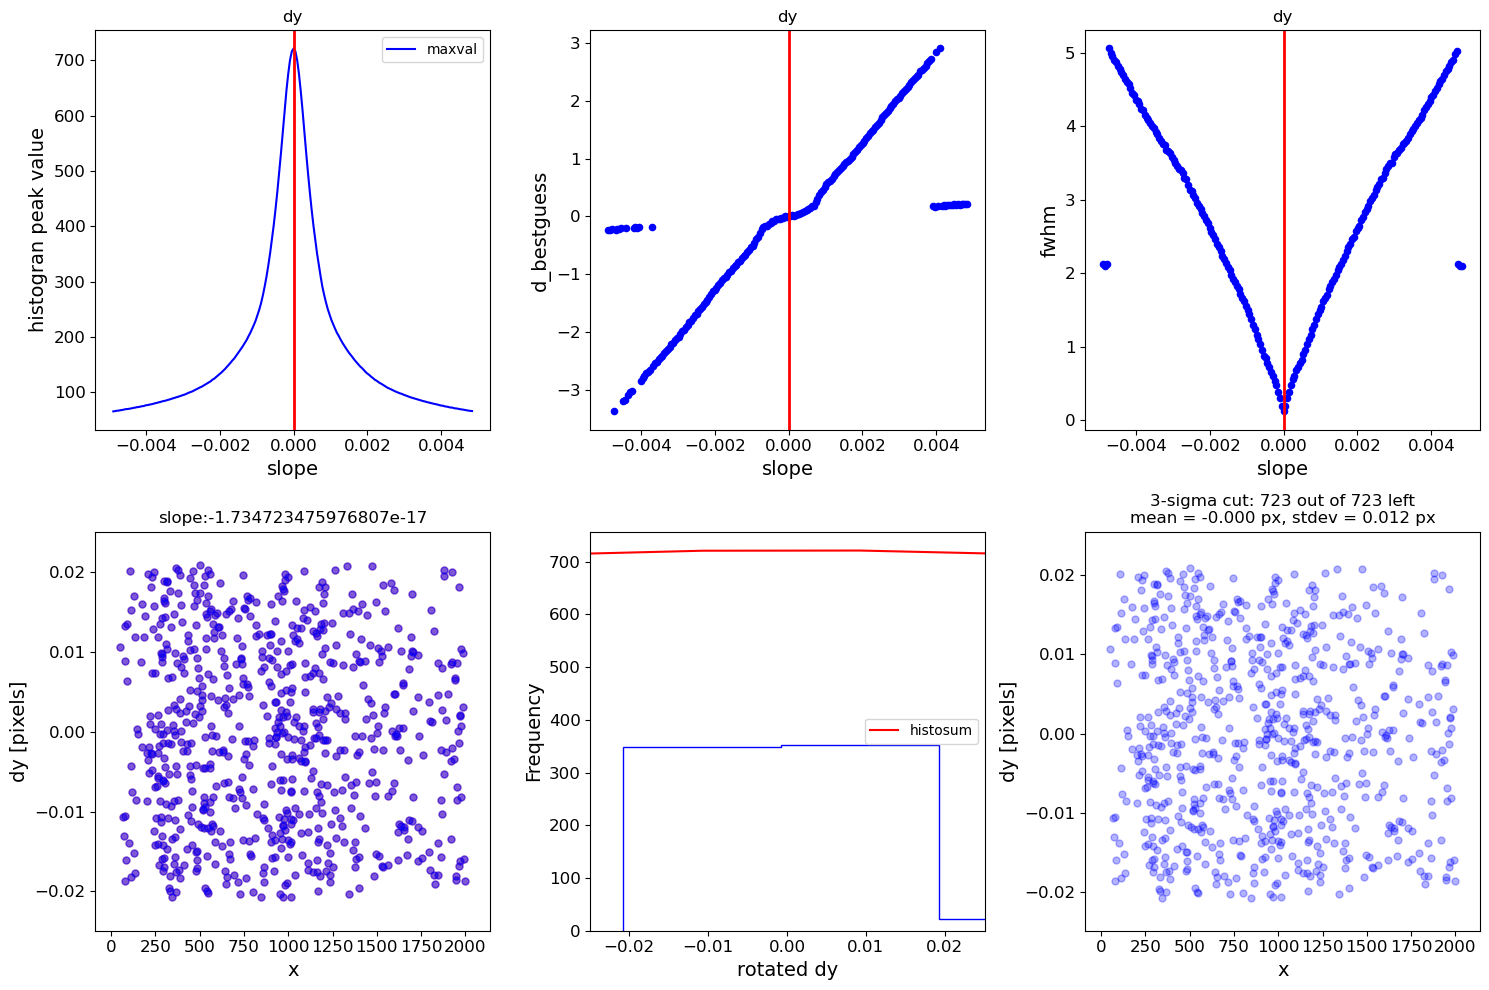

*** Note: close plots to continue!


<Figure size 640x480 with 0 Axes>

WWWWWWWWWWWWWWWWWWWWWWWWWWW run_align2refcat 2026-09-04 11:17:13.907643


replacing SIP ./mastDownload/jw02107041001_02101_00003_nrcblong_jhat.fits


WWWWWWWWWWWWWWWWWWWWWWWWWWW update_phottable_final_wcs 2026-09-04 11:17:20.709213


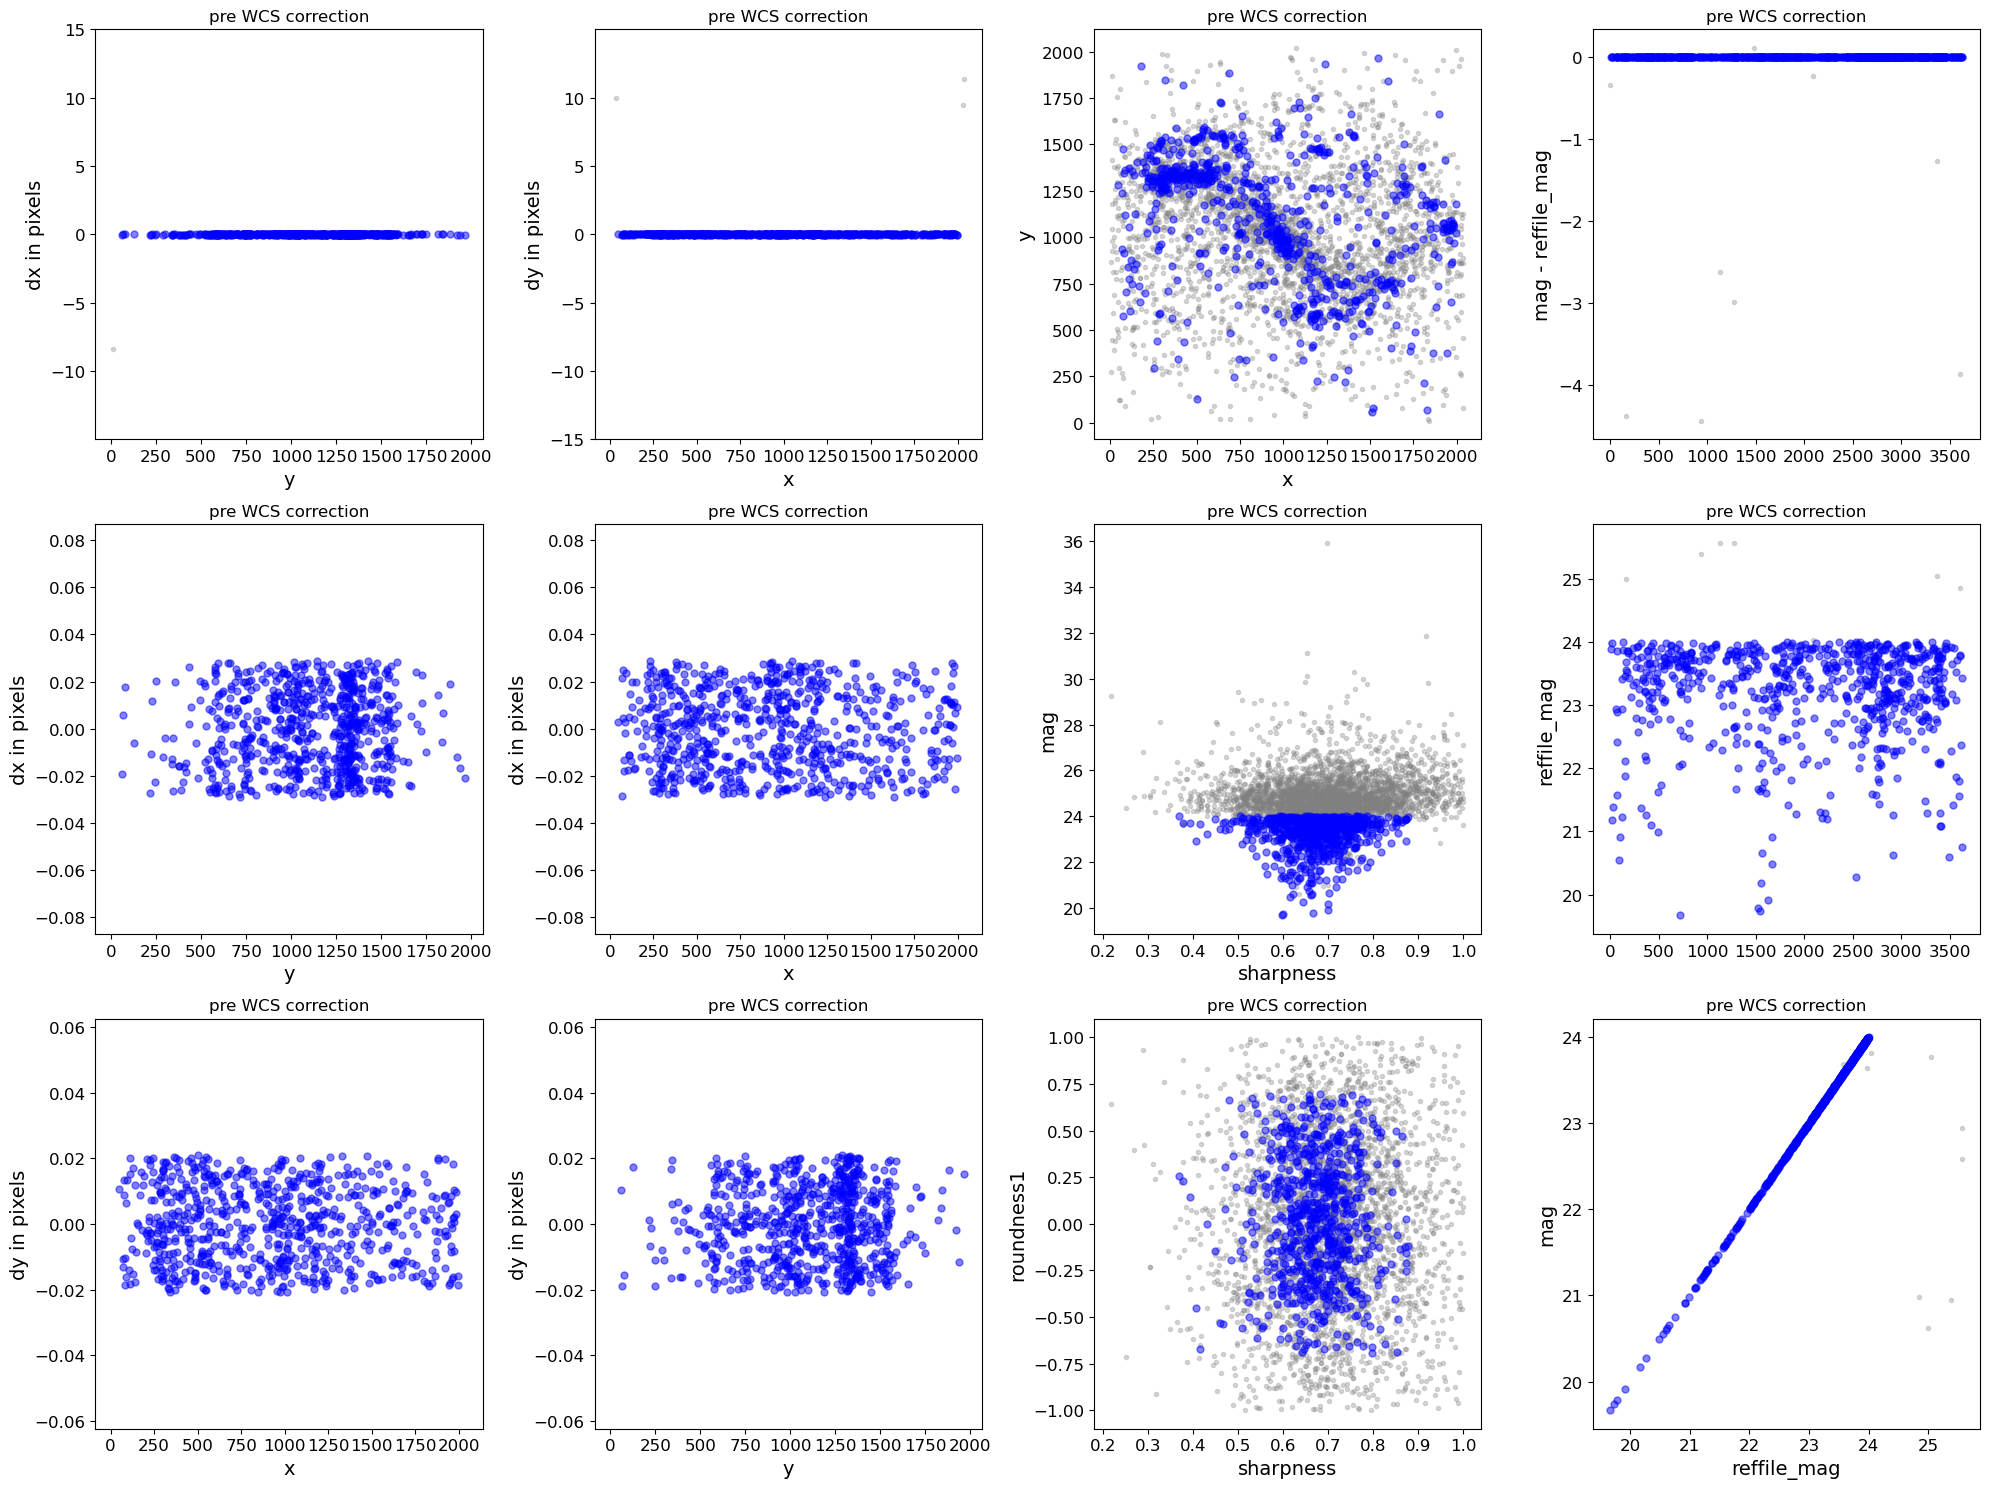

./mastDownload/jw02107041001_02101_00003_nrcblong_jhat.fits


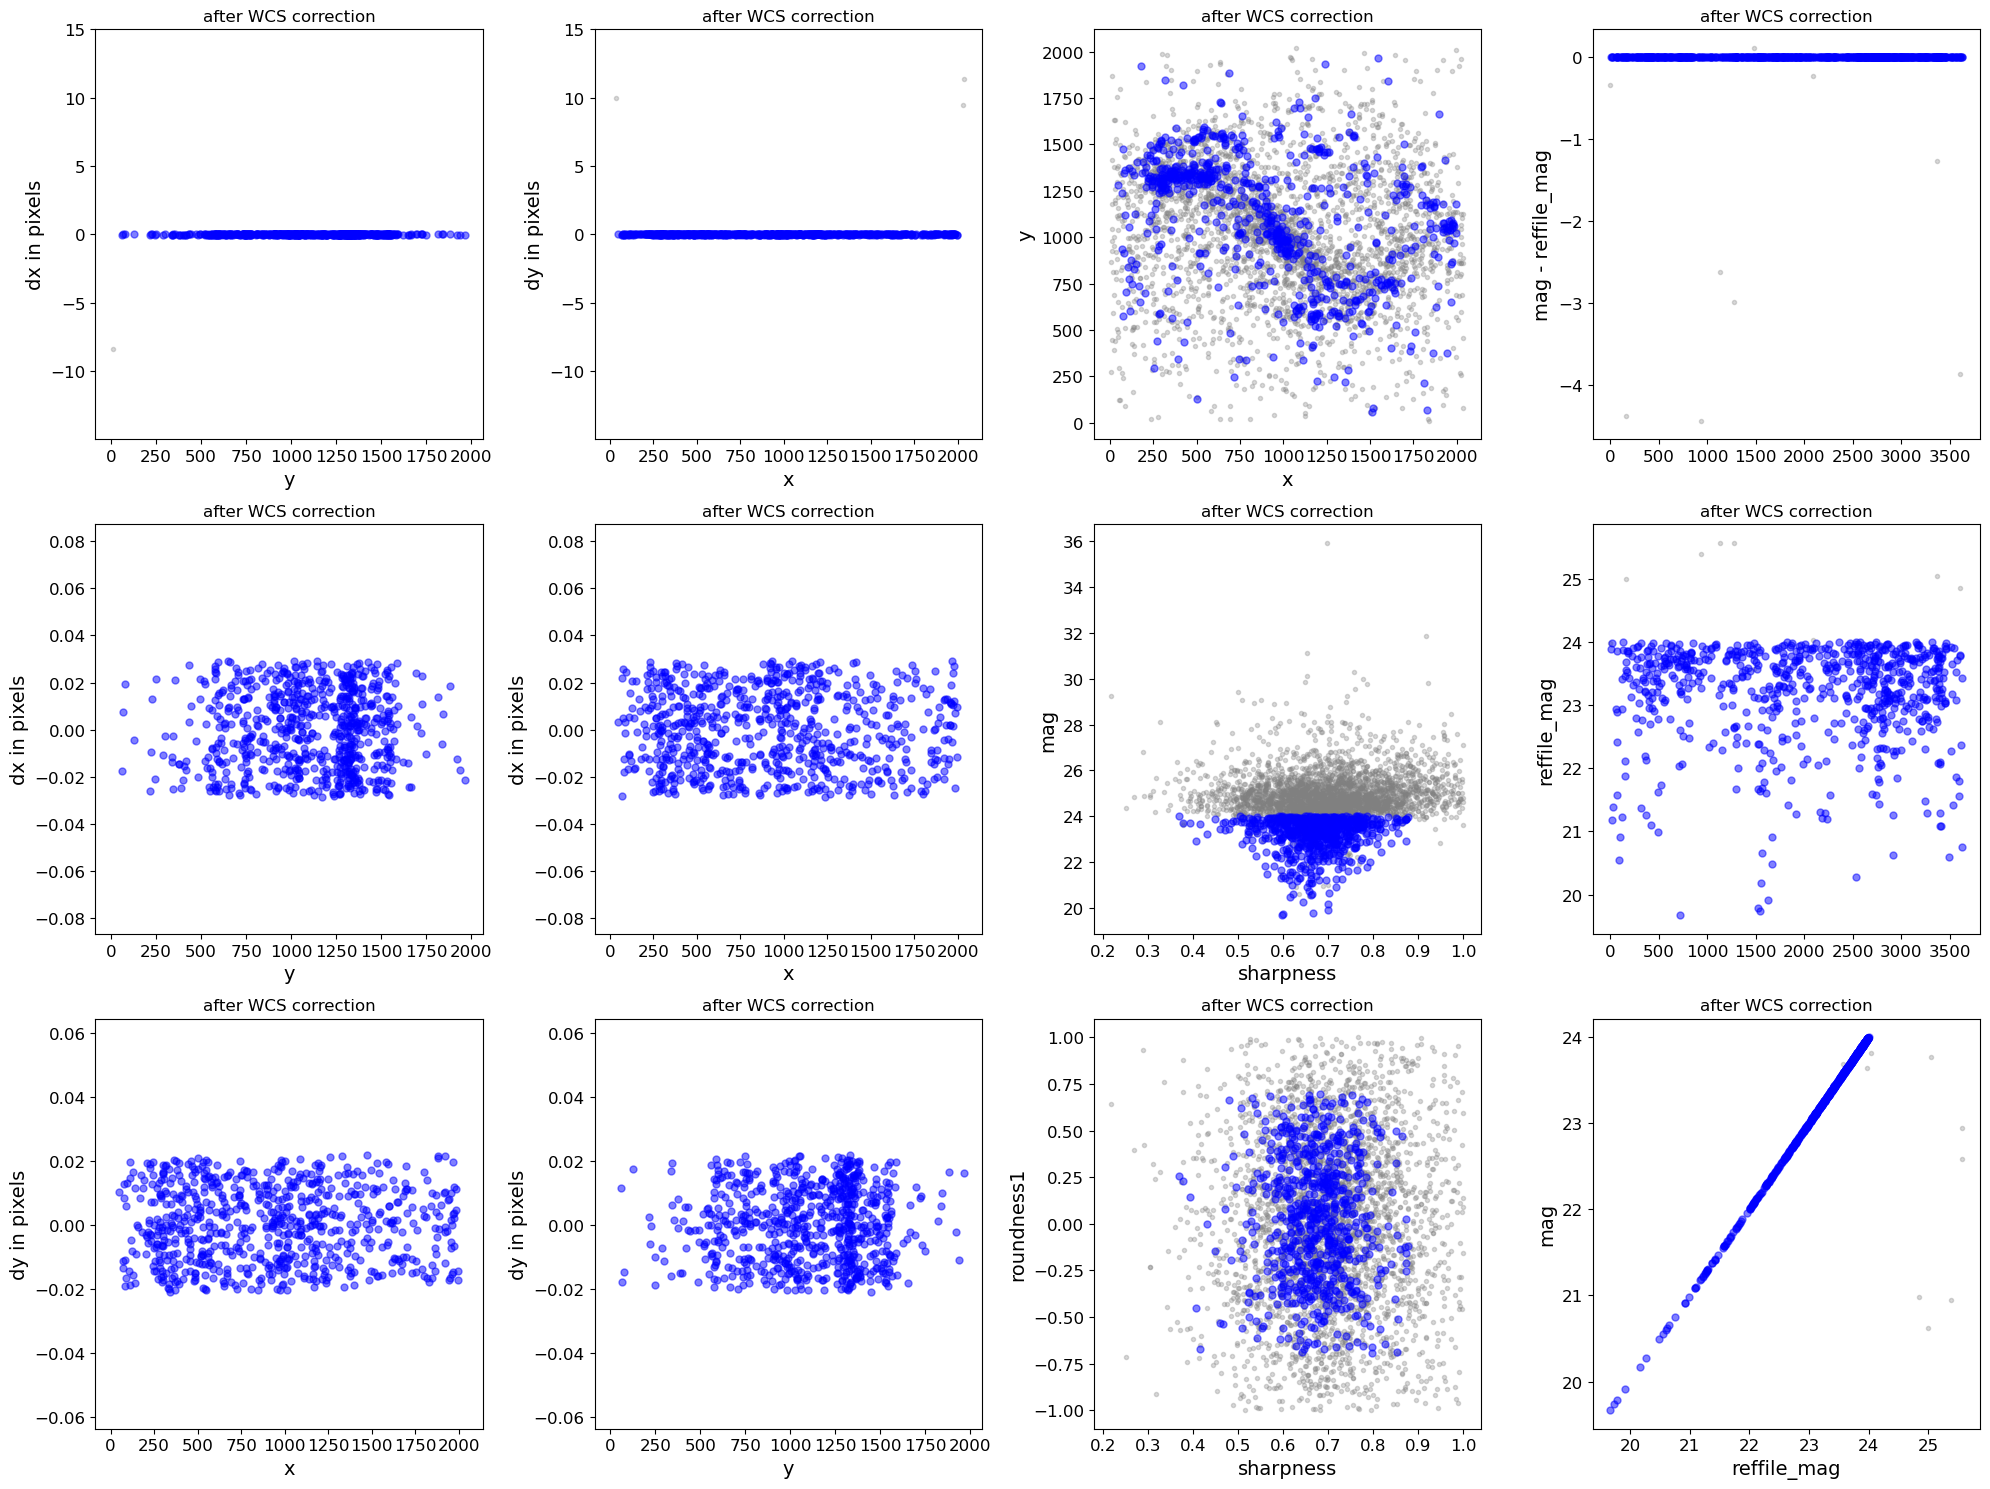

*** Note: close plots to continue!


0

In [ ]:
wcs_align = st_wcs_align()

wcs_align.run_all(align_image,
		  telescope='jwst',
		  outsubdir='mastDownload',
          refcat_racol='ra',
          refcat_deccol='dec',
          refcat_magcol='mag',
          refcat_magerrcol='dmag',
          overwrite=True,
          d2d_max=1,
          showplots=2,
          refcatname=ref_catname,
          histocut_order='dxdy',
              sharpness_lim=(0.3,0.9),
              roundness1_lim=(-0.7, 0.7),
              SNR_min= 3,
              dmag_max=1.0,
              objmag_lim =(14,24))

**Check the Output**

The reference image has not changed, but let's read in the newly
aligned image and compare with the original. 
subsequent correction needed for optimal alignment.



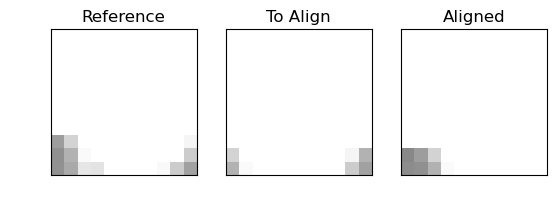

In [14]:
aligned_image = os.path.join('mastDownload',os.path.basename(align_image).replace('cal.fits','jhat.fits'))
aligned_fits = fits.open(aligned_image)
aligned_data = fits.open(aligned_image)['SCI',1].data
aligned_y,aligned_x = skycoord_to_pixel(star_location,wcs.WCS(aligned_fits['SCI',1],aligned_fits))
aligned_cutout = extract_array(aligned_data,(11,11),(aligned_x,aligned_y))

norm3 = simple_norm(aligned_cutout,stretch='linear',min_cut=-.5,max_cut=3)
fig,axes = plt.subplots(1,3)
axes[0].imshow(ref_cutout, origin='lower',
                      norm=norm1,cmap='gray')
axes[1].imshow(align_cutout, origin='lower',
                      norm=norm2,cmap='gray')
axes[2].imshow(aligned_cutout, origin='lower',
                      norm=norm3,cmap='gray')
axes[0].set_title('Reference')
axes[1].set_title('To Align')
axes[2].set_title('Aligned')
for i in range(3):
	axes[i].tick_params(labelcolor='none',axis='both',color='none')


plt.show()

## Align to Catalog

You can also align each image to the Gaia DR3 catalog, or you
could replace the catalog created in step one with your own
catalog of the field. 



WWWWWWWWWWWWWWWWWWWWWWWWWWW apply_distortion_coefficients 2026-09-04 11:17:46.537728
WWWWWWWWWWWWWWWWWWWWWWWWWWW run_phot 2026-09-04 11:17:46.539156


0 ./mastDownload/jw02107041001_02101_00003_nrcblong.phot.txt
find_stars


2026-09-04 13:17:50,129 - CRDS - ERROR -  (FATAL) CRDS server connection and cache load FAILED.  Cannot continue.
 See https://jwst-crds.stsci.edu/docs/cmdline_bestrefs/
 for more information on configuring CRDS, particularly CRDS_PATH and CRDS_SERVER_URL. : [Errno 2] No such file or directory: '/grp/crds/cache/config/jwst/server_config'


dmag 0.36200000000000004
DDD NIRCAM F360M CLEAR ggg None
####### coron None
dmag 1.0
sharpness 0.9
roundness1 0.7
mag 24


WWWWWWWWWWWWWWWWWWWWWWWWWWW initial_cut_photcat 2026-09-04 11:17:51.387474
WWWWWWWWWWWWWWWWWWWWWWWWWWWXX 1pass 2026-09-04 11:17:51.391923
WWWWWWWWWWWWWWWWWWWWWWWWWWW load_and_match_refcat 2026-09-04 11:17:51.392140


...

    slope  intercept   maxval  index  d_bestguess  fwhm  multimax
-0.002979       3.05 6.813221  51655    13.708885   0.6     False
d_rot_tmp 14.508885268375526
Keeping 9 out of 9, skippin 0 because of null values in columns d_rot_tmp
median: 13.682960
75.000000 percentile cut: max residual for cut: 0.173768
__tmp_residuals 0.1737676185239465
median: 13.661667
i:00 mean:13.661667(0.045561) stdev:0.101877(0.029409) X2norm:0.91 Nchanged:0 Ngood:6 Nclip:3

mean: 13.720312
i:01 mean:13.720312(0.050183) stdev:0.132772(0.033193) X2norm:1.00 Nchanged:2 Ngood:8 Nclip:1

mean: 13.720312
i:02 mean:13.720312(0.050183) stdev:0.132772(0.033193) X2norm:1.00 Nchanged:0 Ngood:8 Nclip:1
    slope  intercept  maxval  index  d_bestguess  fwhm  multimax
-0.004883        5.0     1.0     31  -162.770456  0.28      True
d_rot_tmp -162.07045587340644
Keeping 1 out of 1, skippin 0 because of null values in columns d_rot_tmp
WARNING! i:00 mean:-162.7804558734071(None) stdev:None(None) X2norm:None Nchanged:0 Ngo

WWWWWWWWWWWWWWWWWWWWWWWWWWW run_align2refcat 2026-09-04 11:17:59.131171


replacing SIP ./mastDownload/jw02107041001_02101_00003_nrcblong_jhat.fits


WWWWWWWWWWWWWWWWWWWWWWWWWWW update_phottable_final_wcs 2026-09-04 11:18:05.124221


./mastDownload/jw02107041001_02101_00003_nrcblong_jhat.fits


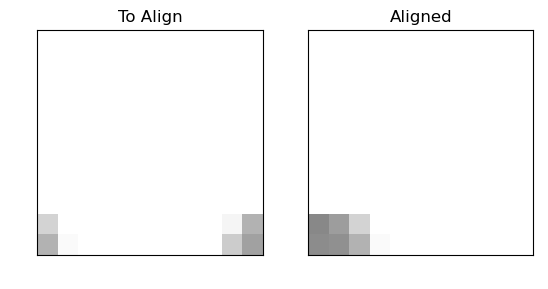

In [ ]:
wcs_align.run_all(align_image,
		  telescope='jwst',
		  outsubdir='mastDownload',
          overwrite=True,
          d2d_max=.5,
          showplots=0,
          refcatname='Gaia',
          histocut_order='dxdy',
              sharpness_lim=(0.3,0.9),
              roundness1_lim=(-0.7, 0.7),
              SNR_min= 3,
              dmag_max=1.0,
              objmag_lim =(14,24))

aligned_image = os.path.join('mastDownload',os.path.basename(align_image).replace('cal.fits','jhat.fits'))
aligned_fits = fits.open(aligned_image)
aligned_data = fits.open(aligned_image)['SCI',1].data
aligned_y,aligned_x = skycoord_to_pixel(star_location,wcs.WCS(aligned_fits['SCI',1],aligned_fits))
aligned_cutout = extract_array(aligned_data,(11,11),(aligned_x,aligned_y))

norm3 = simple_norm(aligned_cutout,stretch='linear',min_cut=-.5,max_cut=3)
fig,axes = plt.subplots(1,2)

axes[0].imshow(align_cutout, origin='lower',
                      norm=norm2,cmap='gray')
axes[1].imshow(aligned_cutout, origin='lower',
                      norm=norm3,cmap='gray')
axes[0].set_title('To Align')
axes[1].set_title('Aligned')
for i in range(2):
	axes[i].tick_params(labelcolor='none',axis='both',color='none')


plt.show()